## <center> Predicting Movie Rental Durations <center>

In [452]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import operator as op

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

In [453]:
# Import the rental_info.csv dataset
rental_df = pd.read_csv("datasets/rental_info.csv", parse_dates=["rental_date", "return_date"])
rental_df.head()

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401


In [454]:
# Review the data frame info
rental_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   rental_date       15861 non-null  datetime64[ns, UTC]
 1   return_date       15861 non-null  datetime64[ns, UTC]
 2   amount            15861 non-null  float64            
 3   release_year      15861 non-null  float64            
 4   rental_rate       15861 non-null  float64            
 5   length            15861 non-null  float64            
 6   replacement_cost  15861 non-null  float64            
 7   special_features  15861 non-null  object             
 8   NC-17             15861 non-null  int64              
 9   PG                15861 non-null  int64              
 10  PG-13             15861 non-null  int64              
 11  R                 15861 non-null  int64              
 12  amount_2          15861 non-null  float64            
 13  l

In [455]:
# Shape of the data frame
rental_df.shape

(15861, 15)

In [456]:
# Create a 'rental_length_days' columns by subtracting the rental_date from the return_date
rental_df["rental_length_days"] = rental_df["return_date"] - rental_df["rental_date"]
rental_df["rental_length_days"] = rental_df["rental_length_days"].dt.days

In [457]:
# Examine the first few lines of the rental_df data frame
rental_df.head()

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,3
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,7
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,4


In [458]:
# Examine the values of the 'special_features' column
rental_df["special_features"].unique()

array(['{Trailers,"Behind the Scenes"}', '{Trailers}',
       '{Commentaries,"Behind the Scenes"}', '{Trailers,Commentaries}',
       '{"Deleted Scenes","Behind the Scenes"}',
       '{Commentaries,"Deleted Scenes","Behind the Scenes"}',
       '{Trailers,Commentaries,"Deleted Scenes"}',
       '{"Behind the Scenes"}',
       '{Trailers,"Deleted Scenes","Behind the Scenes"}',
       '{Commentaries,"Deleted Scenes"}', '{Commentaries}',
       '{Trailers,Commentaries,"Behind the Scenes"}',
       '{Trailers,"Deleted Scenes"}', '{"Deleted Scenes"}',
       '{Trailers,Commentaries,"Deleted Scenes","Behind the Scenes"}'],
      dtype=object)

In [459]:
# Delete the '}', '{', and '"' in 'special_features'
rental_df["special_features"] = rental_df["special_features"].str.replace('{', '')
rental_df["special_features"] = rental_df["special_features"].str.replace('}', '')
rental_df["special_features"] = rental_df["special_features"].str.replace('"', '')

In [460]:
# Convert values in the 'special_features' column to lists
rental_df["special_features"] = rental_df["special_features"].to_list()

In [461]:
# Create the column 'deleted_scenes' and assign '1' to rows that contain the phrase 'Deleted Scenes'
for index, value in rental_df["special_features"].items():
    if op.contains(value, 'Deleted'):
        rental_df.loc[index, "deleted_scenes"] = 1
    else:
        rental_df.loc[index, "deleted_scenes"] = 0

In [462]:
# Sample the data frame to ensure the 'deleted_scenes' column contains correct values
rental_df.sample(n=15, replace = False)

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days,deleted_scenes
14138,2005-06-17 18:19:00+00:00,2005-06-26 12:38:00+00:00,8.99,2009.0,4.99,120.0,28.99,Behind the Scenes,0,0,1,0,80.8201,14400.0,24.9001,8,0.0
6275,2005-08-18 03:49:43+00:00,2005-08-22 01:00:43+00:00,1.99,2007.0,0.99,74.0,20.99,"Trailers,Commentaries,Deleted Scenes",0,1,0,0,3.9601,5476.0,0.9801,3,1.0
5314,2005-08-01 18:59:50+00:00,2005-08-07 15:38:50+00:00,7.99,2004.0,4.99,49.0,22.99,"Trailers,Commentaries,Deleted Scenes,Behind th...",1,0,0,0,63.8401,2401.0,24.9001,5,1.0
5834,2005-07-28 03:28:47+00:00,2005-08-02 23:51:47+00:00,4.99,2004.0,4.99,175.0,21.99,"Trailers,Deleted Scenes",1,0,0,0,24.9001,30625.0,24.9001,5,1.0
290,2005-08-02 11:52:20+00:00,2005-08-07 11:24:20+00:00,2.99,2010.0,2.99,166.0,10.99,Commentaries,0,0,1,0,8.9401,27556.0,8.9401,4,0.0
1769,2005-07-09 13:43:21+00:00,2005-07-13 11:29:21+00:00,1.99,2008.0,0.99,93.0,29.99,"Trailers,Commentaries,Behind the Scenes",0,0,0,0,3.9601,8649.0,0.9801,3,0.0
656,2005-06-20 19:53:59+00:00,2005-06-27 14:54:59+00:00,2.99,2004.0,2.99,167.0,20.99,Trailers,0,0,0,1,8.9401,27889.0,8.9401,6,0.0
5156,2005-06-20 17:50:00+00:00,2005-06-27 12:18:00+00:00,6.99,2009.0,2.99,179.0,16.99,"Commentaries,Deleted Scenes,Behind the Scenes",0,0,0,1,48.8601,32041.0,8.9401,6,1.0
10470,2005-05-31 02:18:35+00:00,2005-06-05 03:36:35+00:00,2.99,2004.0,0.99,161.0,17.99,"Trailers,Commentaries",0,1,0,0,8.9401,25921.0,0.9801,5,0.0
5292,2005-08-22 20:40:21+00:00,2005-08-28 17:33:21+00:00,2.99,2009.0,2.99,65.0,12.99,"Trailers,Deleted Scenes",0,1,0,0,8.9401,4225.0,8.9401,5,1.0


In [463]:
# Create the column 'behind_the_scenes' and assign '1' to rows that contain the phrase 'Behind the Scenes'
for index, value in rental_df["special_features"].items():
    if op.contains(value, "Behind"):
        rental_df.loc[index, "behind_the_scenes"] = 1
    else:
        rental_df.loc[index, "behind_the_scenes"] = 0

In [464]:
# Sample the data frame to ensure the 'behind_the_scenes' column contains correct values
rental_df.sample(n = 15, replace = False)

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days,deleted_scenes,behind_the_scenes
7890,2005-07-06 16:52:44+00:00,2005-07-08 21:22:44+00:00,4.99,2006.0,4.99,173.0,14.99,Behind the Scenes,0,0,0,1,24.9001,29929.0,24.9001,2,0.0,1.0
11191,2005-08-01 19:52:01+00:00,2005-08-09 22:58:01+00:00,5.99,2007.0,4.99,48.0,9.99,"Deleted Scenes,Behind the Scenes",1,0,0,0,35.8801,2304.0,24.9001,8,1.0,1.0
15233,2005-07-29 08:47:37+00:00,2005-08-02 11:25:37+00:00,2.99,2006.0,2.99,63.0,27.99,"Trailers,Behind the Scenes",0,0,0,1,8.9401,3969.0,8.9401,4,0.0,1.0
4412,2005-07-28 18:23:01+00:00,2005-07-29 15:51:01+00:00,4.99,2010.0,4.99,47.0,21.99,"Commentaries,Deleted Scenes,Behind the Scenes",1,0,0,0,24.9001,2209.0,24.9001,0,1.0,1.0
2492,2005-06-19 20:05:47+00:00,2005-06-27 01:34:47+00:00,5.99,2004.0,4.99,170.0,22.99,"Trailers,Deleted Scenes,Behind the Scenes",0,1,0,0,35.8801,28900.0,24.9001,7,1.0,1.0
6536,2005-07-31 11:39:32+00:00,2005-08-06 05:50:32+00:00,4.99,2006.0,4.99,77.0,9.99,"Deleted Scenes,Behind the Scenes",1,0,0,0,24.9001,5929.0,24.9001,5,1.0,1.0
711,2005-06-15 12:09:12+00:00,2005-06-17 08:05:12+00:00,0.99,2005.0,0.99,111.0,12.99,"Commentaries,Deleted Scenes",0,0,0,1,0.9801,12321.0,0.9801,1,1.0,0.0
7595,2005-06-21 01:20:51+00:00,2005-06-29 22:06:51+00:00,4.99,2009.0,0.99,164.0,22.99,Deleted Scenes,0,0,0,1,24.9001,26896.0,0.9801,8,1.0,0.0
14415,2005-07-11 08:34:49+00:00,2005-07-16 13:33:49+00:00,4.99,2006.0,4.99,103.0,11.99,Deleted Scenes,1,0,0,0,24.9001,10609.0,24.9001,5,1.0,0.0
12611,2005-06-18 18:00:31+00:00,2005-06-22 18:45:31+00:00,0.99,2009.0,0.99,172.0,14.99,"Trailers,Behind the Scenes",0,0,0,1,0.9801,29584.0,0.9801,4,0.0,1.0


In [465]:
# X data frame with all the appropriate features that can be used to run the regression models
X = rental_df[["amount","amount_2", "rental_rate", "rental_rate_2", "release_year", "length", "length_2", "replacement_cost", "NC-17", "PG", "PG-13", "R", "deleted_scenes", "behind_the_scenes"]]
X.head()

,amount,amount_2,rental_rate,rental_rate_2,release_year,length,length_2,replacement_cost,NC-17,PG,PG-13,R,deleted_scenes,behind_the_scenes
0,2.99,8.9401,2.99,8.9401,2005.0,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
1,2.99,8.9401,2.99,8.9401,2005.0,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
2,2.99,8.9401,2.99,8.9401,2005.0,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
3,2.99,8.9401,2.99,8.9401,2005.0,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
4,2.99,8.9401,2.99,8.9401,2005.0,126.0,15876.0,16.99,0,0,0,1,0.0,1.0


In [466]:
# Check the shape of X
X.shape

(15861, 14)

In [467]:
# Check for missing data in X
X.isna().sum()

amount               0
amount_2             0
rental_rate          0
rental_rate_2        0
release_year         0
length               0
length_2             0
replacement_cost     0
NC-17                0
PG                   0
PG-13                0
R                    0
deleted_scenes       0
behind_the_scenes    0
dtype: int64

In [468]:
# Convert "release_year" to integer
X["release_year"] = X["release_year"].astype(int)
X.head()

C:\Users\uyen\AppData\Local\Temp\ipykernel_18632\3797629229.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["release_year"] = X["release_year"].astype(int)


,amount,amount_2,rental_rate,rental_rate_2,release_year,length,length_2,replacement_cost,NC-17,PG,PG-13,R,deleted_scenes,behind_the_scenes
0,2.99,8.9401,2.99,8.9401,2005,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
1,2.99,8.9401,2.99,8.9401,2005,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
2,2.99,8.9401,2.99,8.9401,2005,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
3,2.99,8.9401,2.99,8.9401,2005,126.0,15876.0,16.99,0,0,0,1,0.0,1.0
4,2.99,8.9401,2.99,8.9401,2005,126.0,15876.0,16.99,0,0,0,1,0.0,1.0


In [469]:
# Set the "rental_length_days" column to y
y = rental_df["rental_length_days"]

In [470]:
# Split the data frame into train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 9 , test_size = 0.2)

In [471]:
# Create a pipeline to scale and apply the Linear Regression model
# Instantiate a Linear Regression model
lr = LinearRegression()
# Instantiate StandardScaler
scaler = StandardScaler()
# Scale the X_train
X_train_scaled = scaler.fit_transform(X_train)
# Scale the X_test
X_test_scaled= scaler.transform(X_test)
# Fit the train data to the Linear Regression model
lr.fit(X_train_scaled, y_train)
# Predict the test data
lr_y_pred = lr.predict(X_test_scaled)
# Print the R2 score of the test data and the MSE
print("R2 score:", lr.score(X_test_scaled, lr_y_pred),"\n", 
      "MSE:", MSE(y_test, lr_y_pred))

R2 score: 1.0 
 MSE: 2.9417238646975976


In [472]:
# Decision Tree Regressor
# Instantiate a Regression Tree
dt = DecisionTreeRegressor(max_depth = 8, min_samples_leaf= 0.13, random_state = 9)
# Fit the regression tree to train data
dt.fit(X_train, y_train)
# Predict the test data
dt_y_pred = dt.predict(X_test)
# Print the MSE
mse_dt = MSE(y_test, dt_y_pred)
print("Decision Tree MSE:", mse_dt)

Decision Tree MSE: 3.3215025669433933


In [473]:
# Bagging Regressor
# Instantiate Bagging Regressor
br = BaggingRegressor(estimator=dt, n_estimators=50, random_state=9)
# Fit br to the training set
br.fit(X_train, y_train)
# Predict the test data
br_y_pred = br.predict(X_test)
# Print the MSE
mse_br = MSE(y_test, br_y_pred)
print("Bagging Regressor MSE:", mse_br)

Bagging Regressor MSE: 4.3857301023073605


RF MSE: 2.037358013206522


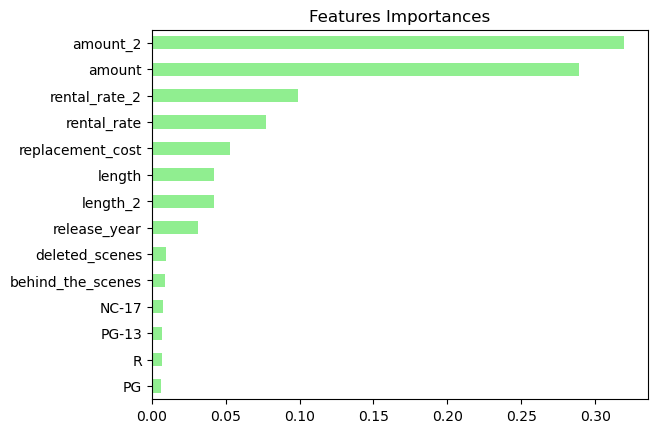

In [474]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=50, random_state=9)
# Fit rf to the training set
rf.fit(X_train, y_train)
# Predict the test data
rf_y_pred = rf.predict(X_test)
# Print the MSE
mse_rf = MSE(y_test, rf_y_pred)
print("RF MSE:", mse_rf)

# Create a pd.Series of features importances
importances = pd.Series(data=rf.feature_importances_,
                        index= X_train.columns)
# Sort importances
importances_sorted = importances.sort_values()
# Draw a horizontal barplot of importances_sorted
importances_sorted.plot(kind='barh', color='lightgreen')
plt.title('Features Importances')
plt.show()

In [475]:
# AdaBoost
# Instantiate AdaBoost
ada = AdaBoostRegressor(estimator=dt, n_estimators=180, random_state=9)
# Fit ada to the training set
ada.fit(X_train, y_train)
# Predict the test data
ada_y_pred = ada.predict(X_test)
# Print the MSE
mse_ada = MSE(y_test, ada_y_pred)
print("MSE AdaBoost:", mse_ada)

MSE AdaBoost: 3.121541877223842


In [476]:
# Gradient Boosting
# Instantiate Gradient Boosting
gb = GradientBoostingRegressor(max_depth = 8, n_estimators = 50, random_state=9)
# Fit to training data
gb.fit(X_train, y_train)
# Predict the test data
gb_y_pred = gb.predict(X_test)
# Print the mse
mse_gb = MSE(y_test, gb_y_pred)
print("MSE Gradient Boosting:", mse_gb)

MSE Gradient Boosting: 2.086557157221568


In [477]:
# Hyperparameter Tuning for Decision Tree
# Instantiate dt
dt = DecisionTreeRegressor(random_state=9)
# Define params_dt
params_dt = {
    'max_depth': [2,3,4,5,6,7,8],
    'min_samples_leaf': [0.12, 0.14, 0.16, 0.18, 0.20]
}
# Instantiate Grid Search CV
grid_dt = GridSearchCV(estimator = dt, param_grid=params_dt, scoring = 'neg_mean_squared_error', cv = 10, verbose  = 1, n_jobs = -1)
# Fit to the training data
grid_dt.fit(X_train, y_train)
# Extract the best estimator (model)
best_model = grid_dt.best_estimator_
# Print the best params
best_params = grid_dt.best_params_
print("Best params:", best_params)
# Make predictions and evaluate on test data
grid_dt_y_pred = best_model.predict(X_test)
#  MSE
grid_dt_mse = MSE(y_test, grid_dt_y_pred)
print("MSE:", grid_dt_mse)


Fitting 10 folds for each of 35 candidates, totalling 350 fits
Best params: {'max_depth': 5, 'min_samples_leaf': 0.12}
MSE: 3.274658361722676


In [478]:
# Hyperparameter Tuning for Random Forest
# Instantiate Random Forest Regressor
rf = RandomForestRegressor(random_state=9)
# Define params_rf
params_rf = {
    'n_estimators': [100, 350, 500],
    'max_features': ['log2','sqrt', None],
    'min_samples_leaf': [2, 10, 30]
}
# Instantiate Grid Search CV
grid_rf = GridSearchCV(estimator = rf, param_grid=params_rf, scoring = "neg_mean_squared_error", cv = 3, verbose = 1, n_jobs = -1)
# Fit to the training data
grid_rf.fit(X_train, y_train)
# Extract the best estimator (model)
best_model = grid_rf.best_estimator_
# Print the best params
best_params = grid_rf.best_params_
print("Best params:", best_params)
# Make predictions and evaluate on test data
grid_rf_y_pred = best_model.predict(X_test)
# MSE
grid_rf_mse = MSE(y_test, grid_rf_y_pred)
print("MSE:", grid_rf_mse)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 500}
MSE: 2.025324702696925


In [479]:
# Save the model you would recommend as a variable named 'best_model'
best_model = best_model

In [480]:
# Save the best MSE on the test set as 'best_mse'
best_mse = grid_rf_mse